<a href="https://colab.research.google.com/github/jelaenas/CESISTA-KJ-DSC1105/blob/main/CESISTA%2CKJ-FA2%20GROUP%2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
cytof  <- read.csv("cytof_one_experiment.csv")

glimpse(cytof)

Rows: 50,000
Columns: 35
$ NKp30         <dbl> 0.1875955, 1.0348518, 2.9996398, 4.2998594, -0.4386448, …
$ KIR3DL1       <dbl> 3.61569324, 1.70018202, 6.14114186, -0.22115860, -0.5035…
$ NKp44         <dbl> -0.56056938, -0.28896114, 1.90326057, 0.24257068, -0.152…
$ KIR2DL1       <dbl> -0.29366542, -0.47982795, 0.48231016, -0.48312672, 0.750…
$ GranzymeB     <dbl> 2.47789290, 3.26101610, 4.27756173, 3.35180809, 3.194145…
$ CXCR6         <dbl> -0.14470053, -0.03392447, 1.94654156, 0.92622195, -0.058…
$ CD161         <dbl> -0.3152872, -0.4112129, -0.5022347, 3.8772370, 1.0907379…
$ KIR2DS4       <dbl> 1.94497046, 3.80251714, -0.32010171, -0.16969487, -0.050…
$ NKp46         <dbl> 4.0818316, 3.7339299, 4.5594631, 4.4831486, 0.8379358, 4…
$ NKG2D         <dbl> 2.62007840, -0.48327879, -0.50690897, 1.92722902, -0.458…
$ NKG2C         <dbl> -0.35738171, -0.46759842, 2.61937825, -0.31101456, 0.921…
$ X2B4          <dbl> -0.27115567, -0.55947525, -0.45547847, 1.63507708, 1.241…
$ CD69         

**Use pivot_longer to reshape the dataset into one that has two columns, the first giving the protein identity and the second giving the amount of the protein in one of the cells. The dataset you get should have 1750000 rows (50000 cells in the original dataset times 35 proteins).**

In [3]:
#pivot_longer

cytof_longer <- cytof %>%
  pivot_longer (
      cols = everything(),
      names_to = "protein",
      values_to = "amount"
  )

#checking number of rows
glimpse(cytof_longer)

Rows: 1,750,000
Columns: 2
$ protein <chr> "NKp30", "KIR3DL1", "NKp44", "KIR2DL1", "GranzymeB", "CXCR6", …
$ amount  <dbl> 0.1875955, 3.6156932, -0.5605694, -0.2936654, 2.4778929, -0.14…


**Use group_by and summarise to find the median protein level and the median absolute deviation of the protein level for each marker. (Use the R functions median and mad**

In [7]:
cytof_summary <- cytof_longer %>%
  group_by(protein) %>%
  summarise(
    median_protein = median(amount),
    mad_protein = mad(amount)
  )

cytof_summary

protein,median_protein,mad_protein
<chr>,<dbl>,<dbl>
CD107a,-0.122299723,0.6086976
CD16,5.122980165,0.8744054
CD161,0.725693301,1.6882296
CD2,3.945378908,1.6770427
CD4,-0.203649896,0.3953896
CD56,5.710790329,0.9981358
CD57,3.070920414,1.9868804
CD69,4.588542784,1.0186438
CD8,2.400718137,2.2887240


**Make a plot with MAD on the x-axis and median on the y-axis. This is known as a spreadlocation (s-l) plot.**

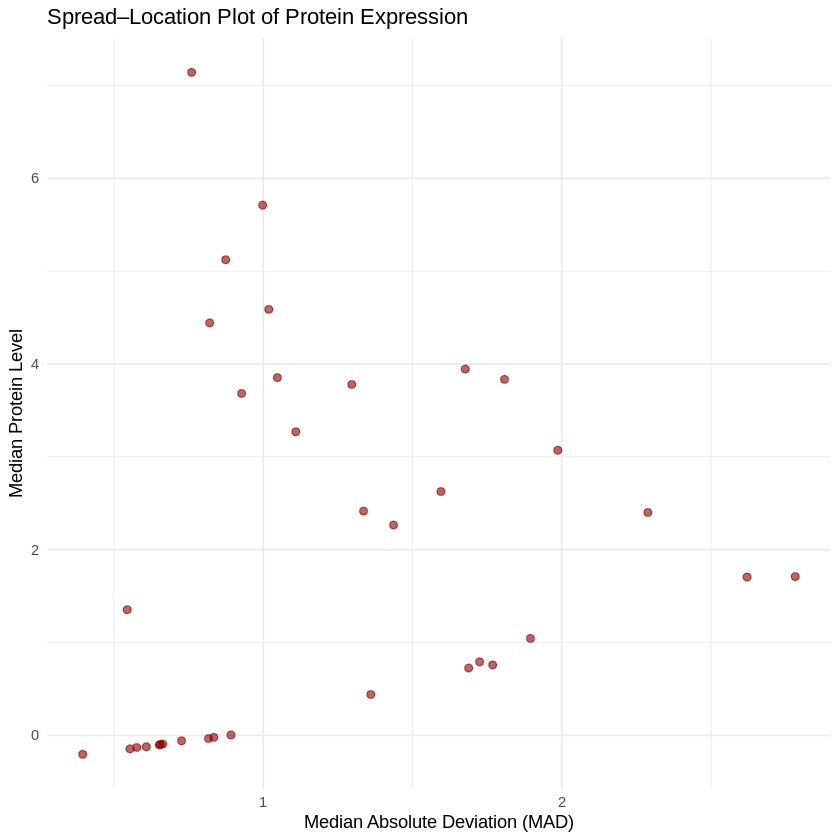

In [18]:
ggplot(cytof_summary, aes(x = mad_protein, y = median_protein)) +
  geom_point(color = "dark red", shape = 20, size = 3, alpha = 0.6) +
  labs(
    x = "Median Absolute Deviation (MAD)",
    y = "Median",
    title = "Spread–Location Plot of Protein"
  ) + theme_minimal()

**What does it tell you about the relationship betwen the median and the MAD?**

For data points with a lower median (location), the MAD (sread) also tends to stay low. However as the median (location) increases, the MAD (spread) also increases, meaning they have more variability. This indicates that there is non-constant variance or heteroscedasticity in the data, wherein variability increases along magnitude of protein expression instead of remaining constant or having homoscedasticity.

**Install the package dcldata using**

**install.packages("remotes")**
**remotes::install_github("dcl-docs/dcldata")**

**(you don’t need the first line if the remotes package is already installed).**

**Load the package using library(dcldata).**

**Load the dataset example_gymnastics_2 using the command data (example_gymnastics_2). Notice that the column names are of the form event_year.**

In [19]:
install.packages("remotes")
remotes::install_github("dcl-docs/dcldata")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpcR54TT/remotes1c13d7a9b9/dcl-docs-dcldata-0a08cbb/DESCRIPTION’ ... OK
* preparing ‘dcldata’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘dcldata_0.1.2.9000.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [26]:
library(dcldata)
data(example_gymnastics_2)

glimpse(example_gymnastics_2)
example_gymnastics_2

Rows: 3
Columns: 5
$ country    <chr> "United States", "Russia", "China"
$ vault_2012 <dbl> 48.132, 46.366, 44.266
$ floor_2012 <dbl> 45.366, 41.599, 40.833
$ vault_2016 <dbl> 46.866, 45.733, 44.332
$ floor_2016 <dbl> 45.999, 42.032, 42.066


country,vault_2012,floor_2012,vault_2016,floor_2016
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
United States,48.132,45.366,46.866,45.999
Russia,46.366,41.599,45.733,42.032
China,44.266,40.833,44.332,42.066


**Using either pivot_longer on its own or pivot_longer in combination with separate, reshape the dataset so that it has columns for country, event, year, and score.**

In [27]:
gymnastics2_long <- example_gymnastics_2 %>%
  pivot_longer(
    cols = -1,
    names_to = "event_year",
    values_to = "score"
  ) %>%
  separate(event_year, into = c("event", "year"), sep = "_")

glimpse(gymnastics2_long)
gymnastics2_long

Rows: 12
Columns: 4
$ country <chr> "United States", "United States", "United States", "United Sta…
$ event   <chr> "vault", "floor", "vault", "floor", "vault", "floor", "vault",…
$ year    <chr> "2012", "2012", "2016", "2016", "2012", "2012", "2016", "2016"…
$ score   <dbl> 48.132, 45.366, 46.866, 45.999, 46.366, 41.599, 45.733, 42.032…


country,event,year,score
<chr>,<chr>,<chr>,<dbl>
United States,vault,2012,48.132
United States,floor,2012,45.366
United States,vault,2016,46.866
United States,floor,2016,45.999
Russia,vault,2012,46.366
Russia,floor,2012,41.599
Russia,vault,2016,45.733
Russia,floor,2016,42.032
China,vault,2012,44.266
